*  DSC 530
*  Final Project
*  Kevin Feracho

# Predicting the Direction of Gold Futures Using Exploratory Data Analysis and Machine Learning

Gold is widely regarded as a safe-haven asset and is frequently analyzed alongside other financial markets such as equities, commodities, and foreign exchange. Because gold prices respond to macroeconomic conditions, analyzing historical price behavior can provide insight into broader financial relationships.

The objective of this project is to analyze historical gold market data using exploratory data analysis (EDA) techniques and machine learning models. The dataset includes daily values for several financial indicators, including the S&P 500 index, gold prices, oil prices, silver prices, and the EUR/USD exchange rate.

The analysis will examine relationships between these variables, explore the statistical properties of gold returns, and attempt to predict whether gold prices move up or down on a given day.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, ttest_1samp

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

# Loading the Dataset

The dataset used in this project was downloaded as a CSV file containing historical financial market data. The dataset includes daily values for several variables including the S&P 500 index, gold prices (GLD), oil prices (USO), silver prices (SLV), and the EUR/USD exchange rate.

In [8]:
gold = pd.read_csv("gld_price_data.csv")

gold.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


# Data Cleaning and Preparation

Before beginning the analysis, the dataset must be cleaned and prepared. The Date column is converted to a datetime format so it can be used for time-series analysis.

Several new variables are created:

Daily_Return – percentage change in gold prices
Direction – binary variable indicating whether gold moved up or down
Volatility_20 – rolling 20-day standard deviation of returns
Lag_Return – previous day's return used as a predictor variable

In [10]:
gold["Date"] = pd.to_datetime(gold["Date"])

gold["Daily_Return"] = gold["GLD"].pct_change()

gold["Direction"] = np.where(gold["Daily_Return"] > 0, 1, 0)

gold["Volatility_20"] = gold["Daily_Return"].rolling(20).std()

gold["Lag_Return"] = gold["Daily_Return"].shift(1)

gold = gold.dropna()

gold.head()

,Date,SPX,GLD,USO,SLV,EUR/USD,Daily_Return,Direction,Volatility_20,Lag_Return
20,2008-01-31,1378.550049,91.400002,72.349998,16.818001,1.486503,-0.007169,0,0.011941,0.009983
21,2008-02-01,1395.420044,89.349998,70.470001,16.618999,1.479991,-0.022429,0,0.013235,-0.007169
22,2008-02-04,1380.819946,89.099998,71.370003,16.514999,1.482800,-0.002798,0,0.013176,-0.022429
23,2008-02-05,1336.640015,87.680000,70.150002,16.167000,1.463807,-0.015937,0,0.013733,-0.002798
24,2008-02-06,1326.449951,88.949997,69.019997,16.375000,1.461710,0.014484,1,0.013098,-0.015937


# Summary Statistics

Summary statistics provide an overview of the central tendency and variability of the data. These statistics help describe the distribution of gold returns and volatility within the dataset.

In [19]:
gold[["GLD","Daily_Return","Volatility_20","Lag_Return"]].describe()

,GLD,Daily_Return,Volatility_20,Lag_Return
count,2270.000000,2270.000000,2270.000000,2270.000000
mean,123.038874,0.000210,0.011603,0.000221
std,23.154367,0.012935,0.005884,0.012933
min,70.000000,-0.130685,0.004037,-0.130685
25%,110.354997,-0.005716,0.007883,-0.005702
50%,120.660004,0.000479,0.010055,0.000488
75%,133.092506,0.006339,0.013575,0.006352
max,184.589996,0.112905,0.046941,0.112905


# Distribution of Daily Returns

Financial return distributions often show heavy tails and occasional large price movements. Visualizing the distribution helps identify patterns and potential outliers.

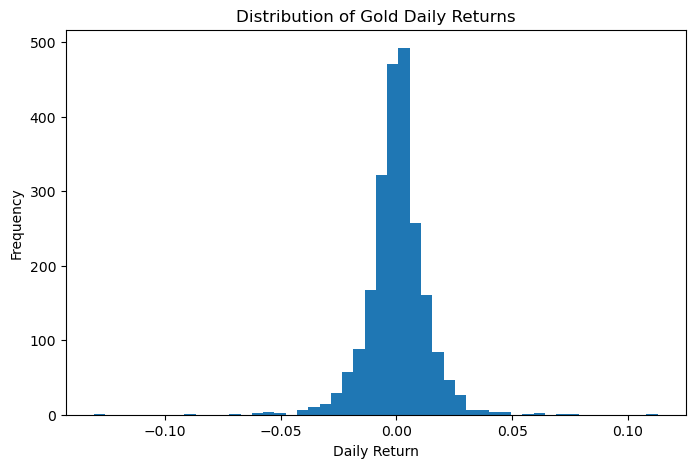

In [20]:
plt.figure(figsize=(8,5))
plt.hist(gold["Daily_Return"], bins=50)

plt.title("Distribution of Gold Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

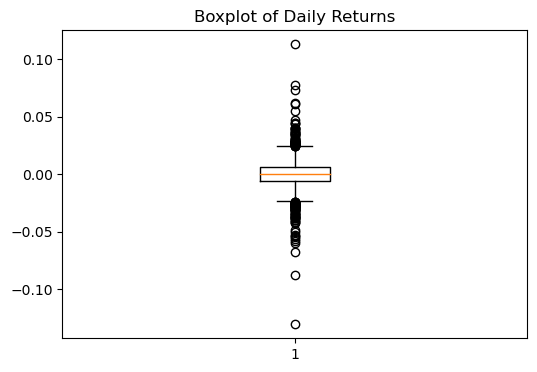

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot(gold["Daily_Return"])

plt.title("Boxplot of Daily Returns")

plt.show()

# Skewness and Kurtosis

Skewness measures the asymmetry of the return distribution while kurtosis measures the heaviness of the tails. Financial returns often exhibit high kurtosis due to occasional extreme movements.

In [22]:
print("Skewness:", skew(gold["Daily_Return"]))
print("Kurtosis:", kurtosis(gold["Daily_Return"]))

Skewness: -0.3424218808386342
Kurtosis: 10.874044459392092


# Correlation Analysis

Correlation analysis helps identify relationships between variables in the dataset. In this project, the correlation between gold prices and several related financial markets is examined. These include the S&P 500 index (SPX), oil prices (USO), silver prices (SLV), and the EUR/USD exchange rate.

Understanding these relationships may help explain movements in gold prices and provide useful information for predictive modeling.

In [17]:
corr_matrix = gold[["SPX", "GLD", "USO", "SLV", "EUR/USD", "Lag_Return", "Volatility_20", "Daily_Return"]].corr()

corr_matrix

,SPX,GLD,USO,SLV,EUR/USD,Lag_Return,Volatility_20,Daily_Return
SPX,1.000000,0.042876,-0.594514,-0.277591,-0.672513,-0.023324,-0.472195,-0.024830
GLD,0.042876,1.000000,-0.163128,0.868729,-0.005137,0.020289,-0.282145,0.023080
USO,-0.594514,-0.163128,1.000000,0.182760,0.826248,-0.004293,0.439390,-0.006097
SLV,-0.277591,0.868729,0.182760,1.000000,0.333061,0.025920,-0.126271,0.026706
EUR/USD,-0.672513,-0.005137,0.826248,0.333061,1.000000,0.025051,0.317920,0.016813
Lag_Return,-0.023324,0.020289,-0.004293,0.025920,0.025051,1.000000,-0.022081,-0.033223
Volatility_20,-0.472195,-0.282145,0.439390,-0.126271,0.317920,-0.022081,1.000000,-0.020922
Daily_Return,-0.024830,0.023080,-0.006097,0.026706,0.016813,-0.033223,-0.020922,1.000000


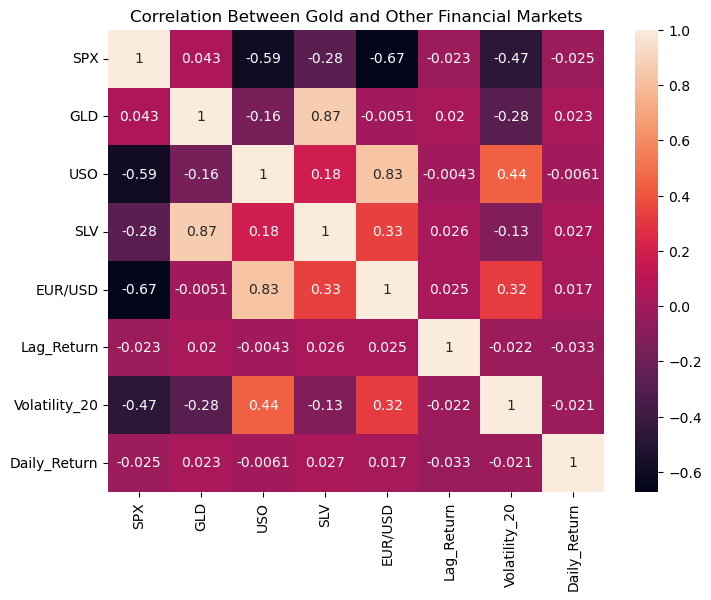

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Between Gold and Other Financial Markets")

plt.show()

# Hypothesis Testing

To examine whether gold exhibits statistically significant daily returns, a one-sample t-test is conducted.

Null Hypothesis (H0): The mean daily return equals zero
Alternative Hypothesis (H1): The mean daily return is different from zero

In [24]:
t_stat, p_value = ttest_1samp(gold["Daily_Return"], 0)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.773350009446129
P-value: 0.43939582478359407


# Logistic Regression Model

A logistic regression model is used to predict whether the gold price will increase or decrease on a given day. The model uses several financial variables as predictors.

In [25]:
X = gold[["SPX","USO","SLV","EUR/USD","Lag_Return","Volatility_20"]]

y = gold["Direction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [26]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [29]:
print("Accuracy:", accuracy_score(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.49632892804698975

Confusion Matrix:
[[ 21 316]
 [ 27 317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.06      0.11       337
           1       0.50      0.92      0.65       344

    accuracy                           0.50       681
   macro avg       0.47      0.49      0.38       681
weighted avg       0.47      0.50      0.38       681



# Random Forest Classifier

A Random Forest classifier is used to compare performance with logistic regression. Random Forest models are capable of capturing nonlinear relationships between variables.

In [30]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.4845814977973568


# Clustering Analysis

Clustering is used to identify patterns in financial markets by grouping similar observations together based on selected variables.

In [31]:
cluster_data = gold[["SPX","USO","SLV","EUR/USD","Daily_Return","Volatility_20"]]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42)

gold["Cluster"] = kmeans.fit_predict(scaled_data)

gold["Cluster"].value_counts()

C:\Users\kevin\OneDrive\School\Classes\Winter_2025\DSC_530\envs\book_env\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kevin\AppData\Local\Temp\ipykernel_62328\1592056254.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold["Cluster"] = kmeans.fit_predict(scaled_data)


Cluster
0    1241
1     822
2     207
Name: count, dtype: int64

# Conclusion

For this project, I analyzed historical gold price data and looked at how it stacked up with several other financial indicators, including the S&P 500, oil prices, silver prices, and the EUR/USD exchange rate. After loading and cleaning the dataset, I created a few additional variables such as daily returns, lagged returns, and a rolling volatility measure. The goal was to explore whether any patterns appeared in the data and to see how gold behaved alongside these other markets.

One of the first things that became obvious during the exploratory analysis was that daily gold price changes are usually pretty small. Most returns stay close to zero, which is generally what you would expect in financial markets where prices move in small increments most of the time. However, the visualizations also showed that there are certain days where the price moves much more than usual. Those larger changes likely reflect times when the market was reacting to bigger economic events or shifts in investor expectations.

When looking at the correlations, gold appeared to have some connection with other commodities like silver and oil. That relationship makes sense since commodities are often affected by similar economic conditions, such as inflation concerns or changes in global demand. At the same time, gold did not seem to move as closely with the stock market or the EUR/USD exchange rate. This suggests that gold can sometimes behave differently from equities and currencies, which helps explain why investors often treat it as a separate type of asset.

I also applied a couple of predictive models, including logistic regression and a random forest classifier, to see if they could determine whether gold prices would rise or fall on a given day. While the models were able to make predictions, the accuracy was not particularly strong. This indicates that even when using several related financial indicators, predicting short-term price direction is still quite challenging.

Overall, the results from this analysis show that gold does have some relationships with other financial markets, especially with other commodities. At the same time, the findings also highlight how complicated financial markets are. Even with multiple variables and modeling techniques, it is still difficult to consistently predict daily price movements in gold.